In [1]:
import requests
import pandas as pd
import geopandas as gpd
import osmnx as ox
import folium

# Obtención de datos

In [2]:
url = "https://pilares.cdmx.gob.mx/api/v1/pilares_search_locations"
payload = {"search": ""} 
headers = {
    "Content-Type": "application/json"
}

r = requests.post(url, json=payload, headers=headers)
data = r.json()

print(data["data"]["location_info"][:1])

[{'pilares_activity_location_id': 1569, 'pilares_activity_location_image': 'https://pilares.cdmx.gob.mx/wp-content/uploads/ae_usercontent/usercontent/63ed771d011ef-069_NT_GAM-100-METROS.jpeg', 'pilares_activity_location_name': '100 METROS', 'pilares_activity_location_address': 'Av Cien Metros y Anillo Periferico S/N , Santiago Atepetlac', 'pilares_activity_location_town': 'GUSTAVO_A_MADERO', 'pilares_activity_location_hours': 'De 09:00 a 19:00', 'pilares_activity_location_coords_lat': '-99.158897', 'pilares_activity_location_coords_lng': '19.526523'}]


In [3]:
nombre = []
direccion = []
alcaldia = []
latitud = []
longitud = []
horario=[]

for pilar in data["data"]["location_info"]:
    nombre.append(pilar["pilares_activity_location_name"])
    direccion.append(pilar["pilares_activity_location_address"])
    alcaldia.append(pilar["pilares_activity_location_town"])
    latitud.append(pilar["pilares_activity_location_coords_lat"])
    longitud.append(pilar["pilares_activity_location_coords_lng"])
    horario.append(pilar["pilares_activity_location_hours"])
    
#Crear tabla
pilares=pd.DataFrame({
    "nombre":nombre,
    "alcaldia":alcaldia,
    "direccion":direccion,
    "latitud":longitud,
    "longitud":latitud,
    "horario":horario
})
print("Total de Pilares:", len(pilares))
pilares.head()

Total de Pilares: 304


,nombre,alcaldia,direccion,latitud,longitud,horario
0,100 METROS,GUSTAVO_A_MADERO,"Av Cien Metros y Anillo Periferico S/N , Santi...",19.526523,-99.158897,De 09:00 a 19:00
1,16 DE SEPTIEMBRE,XOCHIMILCO,Cruce de Anillo Periferico y Av. 16 de Septiem...,19.280984,-99.13733,De 09:00 a 19:00
2,20 DE NOVIEMBRE,VENUSTIANO_CARRANZA,"Avenida Gran Canal s/n 1 , 5to TRAMO 20 DE NOV...",19.447458,-99.103176,De 09:00 a 19:00
3,8 DE AGOSTO,BENITO_JUAREZ,"Río Becerra s/n , 8 de agosto",19.394845,-99.187943,De 09:00 a 19:00
4,ACAHUALTEPEC,IZTAPALAPA,"Calle Colorín s/n, Colonia 1 , Santiago Acahua...",19.346043,-99.008134,De 09:00 a 19:00


In [4]:
pilares['nombre'] = pilares['nombre'].str.title()
pilares['alcaldia'] = (
    pilares['alcaldia'].str.replace("_", " ", regex=False).str.title())

pilares['latitud'] = pd.to_numeric(pilares['latitud'], errors='coerce')
pilares['longitud'] = pd.to_numeric(pilares['longitud'], errors='coerce')
    

pilares.head()

,nombre,alcaldia,direccion,latitud,longitud,horario
0,100 Metros,Gustavo A Madero,"Av Cien Metros y Anillo Periferico S/N , Santi...",19.526523,-99.158897,De 09:00 a 19:00
1,16 De Septiembre,Xochimilco,Cruce de Anillo Periferico y Av. 16 de Septiem...,19.280984,-99.137330,De 09:00 a 19:00
2,20 De Noviembre,Venustiano Carranza,"Avenida Gran Canal s/n 1 , 5to TRAMO 20 DE NOV...",19.447458,-99.103176,De 09:00 a 19:00
3,8 De Agosto,Benito Juarez,"Río Becerra s/n , 8 de agosto",19.394845,-99.187943,De 09:00 a 19:00
4,Acahualtepec,Iztapalapa,"Calle Colorín s/n, Colonia 1 , Santiago Acahua...",19.346043,-99.008134,De 09:00 a 19:00


In [5]:
# 
pilares.isna().sum().sort_values(ascending=False)


longitud     4
latitud      4
alcaldia     0
nombre       0
direccion    0
horario      0
dtype: int64

In [6]:
pilares.loc[pilares['latitud'].isna()]


,nombre,alcaldia,direccion,latitud,longitud,horario
21,Arcoíris,Iztapalapa,"Calle Humberto G. Tamayo s/n 1 , N/D",NaN,NaN,De 09:00 a 19:00
151,Lomas De Tarango,Alvaro Obregon,"N/D 1 , N/D",NaN,NaN,De 09:00 a 19:00
168,Nativitas,Xochimilco,"CAMINO DE NATIVITAS (ZACAPA)S/N 1 , N/D",NaN,NaN,De 09:00 a 19:00
239,San Nicolás Ii,Tlalpan,"Plan de la máquina s/n , San Nicolas II",NaN,NaN,De 09:00 a 19:00


In [7]:
# Editamos pilares con nulos, las coordenadas se buscaron manualmente en google maps
# No se encontro información del Pilares Lomas de Tarango
pilares.loc[21, ['latitud', 'longitud']] = [19.377970469665204, -99.04792719643757]
pilares.loc[168, ['latitud', 'longitud']] = [19.2477487609244, -99.09419025694794] 
pilares.loc[239, ['latitud', 'longitud']] = [19.26768009603627, -99.23764788258909]
# Confirmamos
pilares.loc[pilares['latitud'].isna()]

,nombre,alcaldia,direccion,latitud,longitud,horario
151,Lomas De Tarango,Alvaro Obregon,"N/D 1 , N/D",NaN,NaN,De 09:00 a 19:00


In [8]:
# Espacializamos los datos
gdf = gpd.GeoDataFrame(
    pilares.copy(),
    geometry=gpd.points_from_xy(
        pilares['longitud'],
        pilares['latitud']
        ),
    crs="EPSG:4326"    
)
# Quitamos nulos
print(gdf.shape[0])
gdf = gdf.dropna()
print(gdf.shape[0])
gdf.head()

304
303


,nombre,alcaldia,direccion,latitud,longitud,horario,geometry
0,100 Metros,Gustavo A Madero,"Av Cien Metros y Anillo Periferico S/N , Santi...",19.526523,-99.158897,De 09:00 a 19:00,POINT (-99.1589 19.52652)
1,16 De Septiembre,Xochimilco,Cruce de Anillo Periferico y Av. 16 de Septiem...,19.280984,-99.137330,De 09:00 a 19:00,POINT (-99.13733 19.28098)
2,20 De Noviembre,Venustiano Carranza,"Avenida Gran Canal s/n 1 , 5to TRAMO 20 DE NOV...",19.447458,-99.103176,De 09:00 a 19:00,POINT (-99.10318 19.44746)
3,8 De Agosto,Benito Juarez,"Río Becerra s/n , 8 de agosto",19.394845,-99.187943,De 09:00 a 19:00,POINT (-99.18794 19.39484)
4,Acahualtepec,Iztapalapa,"Calle Colorín s/n, Colonia 1 , Santiago Acahua...",19.346043,-99.008134,De 09:00 a 19:00,POINT (-99.00813 19.34604)


In [10]:
gdf.to_file("pilares.geojson", driver="GeoJSON")


In [2]:
gdf = gpd.read_file("pilares.geojson")

<Axes: >

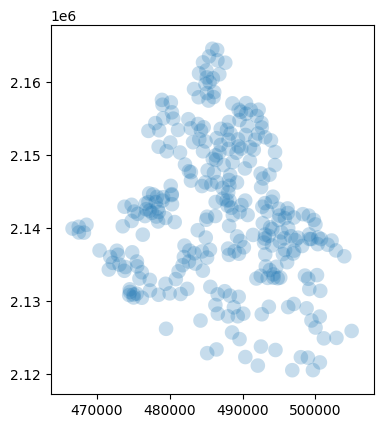

In [3]:
# Creamos buffers de los pilares
# Crear burbujas de isocronas
buffers = gdf.to_crs(epsg="32614")
buffers['geometry'] = buffers.buffer(1000)
buffers.plot(alpha=0.25)

In [7]:
# Descargamos grafo de calles de CDMX de acuerdo a los buffers
# Obtener coordenadas del bounding box de los buffers
bb = [float(x)
      for x in buffers.to_crs(4326).total_bounds]
print(bb)

G = ox.graph.graph_from_bbox(bb, network_type="all", 
                             simplify = False)
G

[-99.32708730680719, 19.168517484897873, -98.94311487435955, 19.58554108635078]


In [8]:
print(len(G.nodes), "nodos")
print(len(G.edges), "aristas")

852096 nodos
1712985 aristas


In [9]:
# Encontrar nodos más cercanos a las paradas de la ruta
nodos_cercanos = ox.distance.nearest_nodes(G,
  [p.x for p in gdf.geometry],
  [p.y for p in gdf.geometry])

In [10]:
# Calles por nodo cercano
# Crear isocronas basadas en las calles
dist_fija = 750  # metros

partes = []
for node in nodos_cercanos:
    edges = ox.convert.graph_to_gdfs(
        ox.truncate.truncate_graph_dist(G, node, dist_fija),
        nodes=False
    ).copy()
    edges["node"] = node
    partes.append(edges[["node", "geometry"]])

iso_edges_por_nodo = gpd.GeoDataFrame(
    pd.concat(partes, ignore_index=True),
    crs=4326
).to_crs(32614)

iso_edges_por_nodo.head()

,node,geometry
0,268533822,"LINESTRING (483333.897 2159097.045, 483335.966..."
1,268533822,"LINESTRING (483333.897 2159097.045, 483320.425..."
2,268533822,"LINESTRING (483312.119 2159144.314, 483302.96 ..."
3,268533822,"LINESTRING (483256.279 2159184.29, 483233.267 ..."
4,268533822,"LINESTRING (483241.805 2159121.341, 483289.242..."


<Axes: >

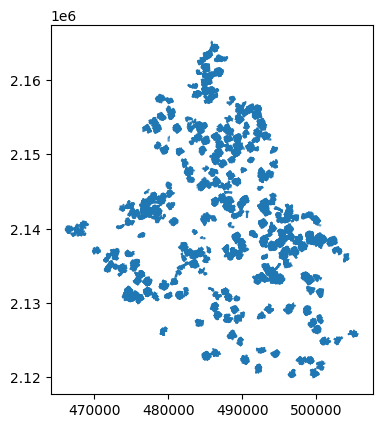

In [11]:
iso_edges_por_nodo.plot()

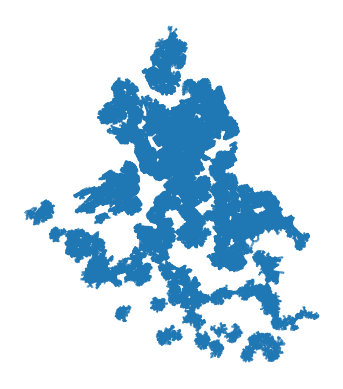

In [ ]:
# UNION ALL
# Crear isocronas basadas en las calles

# dist_fija = 1500  # metros

# isochrone_streets = (
#   gpd.GeoDataFrame(
#     geometry=gpd.GeoSeries(
#       pd.concat([
#         ox.convert.graph_to_gdfs(
#           ox.truncate.truncate_graph_dist(G, node, dist_fija),
#           nodes=False
#         ).geometry
#         for node in nodos_cercanos
#       ]).union_all(),
#       crs=4326
#     )
#   ).to_crs(32614)
# )

# isochrone_streets.plot().set_axis_off()


In [ ]:
# Guardamos isocronas
isochrone_streets.to_file("isocronas_calles_500m_pilares.gpkg", driver="GPKG")

In [87]:
isochrone_streets.to_file("isocronas_calles_1500m_pilares.gpkg", driver="GPKG")

In [14]:
# Guardamos isocronas
iso_edges_por_nodo.to_file("datos/isocronas_calles_750m_pilares_separado.gpkg", driver="GPKG")

In [ ]:
iso_edges_por_nodo = gpd.read_file("datos/calles_750m_pilares_separado.gpkg")

In [15]:
isochrone_streets = iso_edges_por_nodo.copy()

In [16]:
print("Núnmero de segmentos en isocronas:")
print(isochrone_streets.shape[0])
print("Núnmero de nodos en isocronas:")
print(isochrone_streets['node'].nunique())

Núnmero de segmentos en isocronas:
255983
Núnmero de nodos en isocronas:
303


In [14]:
isochrone_streets.head(1)

,node,geometry
0,268533822,"LINESTRING (483794.733 2157720.015, 483760.503..."


In [17]:
gdf_disuelto = isochrone_streets.dissolve(by="node", as_index=False)
print("Núnmero de segmentos en isocronas:")
print(gdf_disuelto.shape[0])
print("Núnmero de nodos en isocronas:")
print(gdf_disuelto['node'].nunique())

Núnmero de segmentos en isocronas:
303
Núnmero de nodos en isocronas:
303


In [19]:
# Guardamos isocronas
gdf_disuelto.to_file("datos/calles_750m_pilares_disuelto.gpkg", driver="GPKG")

In [22]:
isochrone_streets = gdf_disuelto.copy()

<Axes: >

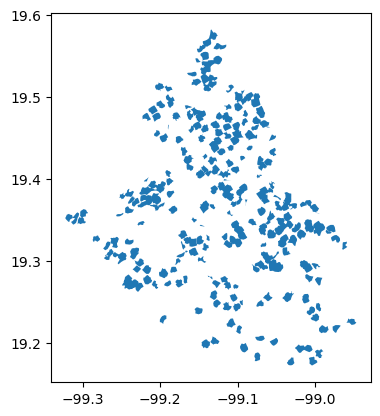

In [ ]:
#
isochrone_approx = (
  isochrone_streets
  .concave_hull(ratio = 0.5)
)

isochrone_approx.plot()

In [25]:
print(isochrone_approx.crs)
print(isochrone_streets.crs)
# print(pilares.crs)

EPSG:32614
EPSG:32614


In [26]:
isochrone_approx = isochrone_approx.to_crs(epsg=4326)
isochrone_streets = isochrone_streets.to_crs(epsg=4326)

In [ ]:
isochrone_approx.to_file("datos/isocronas_calles_750m_pilares_hull.gpkg", driver="GPKG")
isochrone_streets.to_file("datos/calles_750m_pilares.gpkg", driver="GPKG")

In [ ]:
m = folium.Map(
  tiles = None,
  zoom_start = 13, max_bounds = True,
  location = [(bb[0] + bb[2]) / 2, (bb[1] + bb[3]) / 2],
  min_lon = bb[0], min_lat = bb[1], 
  max_lon = bb[2], max_lat = bb[3]
)

folium.TileLayer("CartoDB Positron", overlay = True).add_to(m)


isochrone_approx.explore(
  m = m, name = "Approximate isochrone", tooltip = False,
  style_kwds = dict(color = "red", fill = False, weight = 3))

isochrone_streets.explore(
  m = m, name = "Streets isochrone", tooltip = False,
  style_kwds = dict(color = "orange", weight = 1))

gdf.explore(
  m = m, name = "Pilares", tooltip = "nombre",
  style_kwds = dict(color = "red", fill = False, radius = 6))

folium.LayerControl().add_to(m)
m